# Find edge projectors - circuit cluster states 2
Created 19/08/2026

Objectives:
* Iterate on [this notebook](find_edge_projectors_circuit_cluster_states.ipynb), instead just finding projectors by finding dominant eigenvector of $\rho$.

# Package imports

In [1]:
import sys

In [2]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [4]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [5]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [6]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [7]:
from itertools import cycle

# Definitions

## Construct cluster state

In [8]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [9]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [10]:
np_CZ = np.diag([1,1,1,-1])

In [11]:
np_CZ = np_CZ.reshape((2,)*4)

In [12]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [13]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [14]:
psi = get_cluster_state_qu_tensor_network(32)

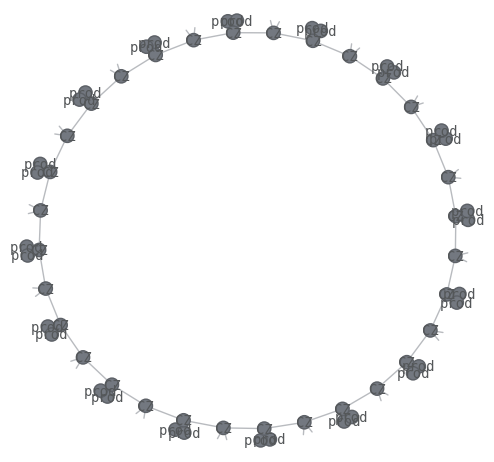

In [15]:
psi.draw()

Looks good. Weird, but good.

## Symmetries and effective density matrices

In [125]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Z = np.array([[1,0],[0,-1]])

In [126]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])
qu_Z = qtn.Tensor(np_Z, inds=['k', 'b'])

In [18]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [19]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [20]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Optimisation functions

In [21]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Extracting projectors

In [22]:
def maximize_projector_states(rho):
    # Assume's rho is a single tensor, not a tensor network.
    k_inds = [i for i in rho.inds if i.startswith('k')]
    b_inds = [i for i in rho.inds if i.startswith('b')]

    rho_flat = (
        rho
        .fuse({'k': k_inds, 'b': b_inds})
        .transpose('k', 'b')
        .data
    )

    eig_vals, eig_vecs = np.linalg.eigh(rho_flat)

    max_i = np.argmax(np.abs(eig_vals))
    score = np.abs(eig_vals[max_i])
    max_vec = eig_vecs[:, max_i]

    quimb_vec = (
        qtn.Tensor(data=max_vec, inds=['k'])
        .unfuse(
            {'k': k_inds},
            shape_map={'k': (2,)*len(k_inds)}
        )
    )

    return score, quimb_vec

In [23]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

# Test

## Left projector

In [24]:
left_rho_sites = [4]

In [25]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})).contract()

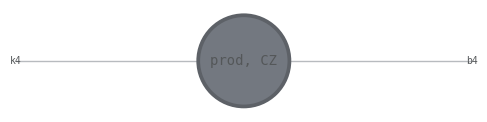

In [26]:
left_rho.draw()

In [27]:
left_score, left_proj_vec = maximize_projector_states(left_rho)

In [28]:
left_score

0.49999999999999645

In [29]:
left_sites = [2,3]
right_sites = [5,6]

In [30]:
larger_sites = left_sites + left_rho_sites + right_sites

In [31]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

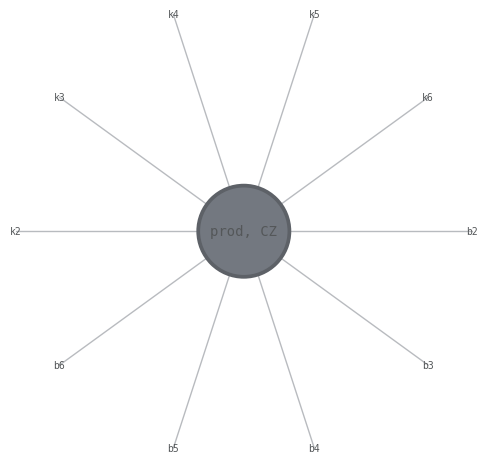

In [32]:
larger_rho.draw()

In [33]:
schmimdt_vals = projector_state_check(
    left_proj_vec,
    larger_rho,
    left_sites
)

In [34]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [35]:
left_proj_vec

Tensor(shape=(2,), inds=('k4',), tags=oset([]))

## Right projector

In [36]:
right_rho_sites = [13]

In [37]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})).contract()

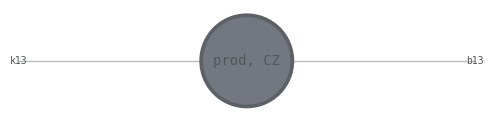

In [38]:
right_rho.draw()

In [39]:
right_score, right_proj_vec = maximize_projector_states(right_rho)

In [40]:
right_score

0.4999999999999965

In [41]:
left_sites = [11,12]
right_sites = [14,15]

In [42]:
larger_sites = left_sites + right_rho_sites + right_sites

In [43]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

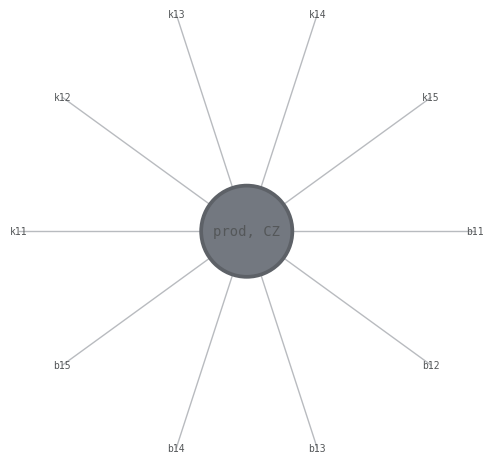

In [44]:
larger_rho.draw()

In [45]:
larger_rho

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k11', 'k12', 'k13', 'k14', 'k15', 'b11', 'b12', 'b13', 'b14', 'b15'), tags=oset(['prod', 'CZ']))

In [46]:
schmimdt_vals = projector_state_check(
    right_proj_vec,
    larger_rho,
    left_sites
)

In [47]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [48]:
proj_psi = (
    psi.reindex({'k4': 'b4', 'k13': 'b13'})
    & left_proj_vec.conj().reindex({'k4': 'b4'})
    & left_proj_vec
    & right_proj_vec.conj().reindex({'k13': 'b13'})
    & right_proj_vec
)

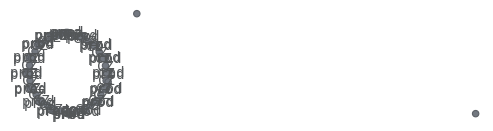

In [49]:
proj_psi.draw()

In [50]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [51]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [52]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [53]:
norm

1.0000000000000004

In [120]:
left_proj_vec

Tensor(shape=(2,), inds=('k4',), tags=oset([]))

In [121]:
right_proj_vec

Tensor(shape=(2,), inds=('k13',), tags=oset([]))

## Compute cut rho

In [54]:
cut_sites = list(range(4, 14))

In [55]:
cut_rho_unprojected = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites}))

In [56]:
cut_rho = (
    cut_rho_unprojected.reindex(
        {
            'k4': 'l4',
            'k13': 'l13',
            'b4': 'c4',
            'b13': 'c13',
        }
    )
    & left_proj_vec.conj().reindex({'k4': 'l4'})
    & left_proj_vec
    & left_proj_vec.reindex({'k4': 'c4'})
    & left_proj_vec.conj().reindex({'k4': 'b4'})
    & right_proj_vec.conj().reindex({'k13': 'l13'})
    & right_proj_vec
    & right_proj_vec.reindex({'k13': 'c13'})
    & right_proj_vec.conj().reindex({'k13': 'b13'})
)

In [57]:
cut_rho_trace = (
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

In [58]:
cut_rho_trace

0.24999999999999822

In [59]:
cut_rho = cut_rho/cut_rho_trace

In [60]:
(
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

1.000000000000001

In [61]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in cut_sites}
    | {f'b{i}': f'k{i}' for i in cut_sites}
)

In [62]:
(
    (cut_rho & cut_rho.reindex(tranpose_map))
    .contract()
)

1.0000000000000022

So the density matrix is pure, nice.

In [63]:
sub_cut_sites = list(range(5, 13))

In [64]:
sub_cut_rho = (
    cut_rho
    .reindex({'k4': 'b4', 'k13': 'b13'})
)

In [65]:
sub_cut_rho_trace = (
    sub_cut_rho
    .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
    .contract()
)

In [66]:
sub_cut_rho_trace

1.000000000000001

In [67]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [68]:
(
    (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
    .contract()
)

1.0000000000000022

## Lanczos algorithm to extract state

In [69]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [70]:
v = qtn.Tensor(
    data=random_uniform_complex((2,)*len(sub_cut_sites)),
    inds=[f'k{i}' for i in sub_cut_sites]
)

In [71]:
transpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [72]:
k_to_b_map = {f'k{i}': f'b{i}' for i in sub_cut_sites}

In [73]:
def lanczos_iteration(rho, v):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [74]:
def lanczos_algorithm(rho, v, num_iters=10):
    for _ in range(num_iters):
        v = lanczos_iteration(rho, v)

    return v

In [75]:
cut_state = lanczos_algorithm(sub_cut_rho, v)

In [76]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12'), tags=oset(['prod', 'CZ']))

In [77]:
(cut_state & cut_state.conj()).contract()

(0.9999999999999996+0j)

In [78]:
rho_state = (
    sub_cut_rho & cut_state.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
).contract()

In [79]:
(rho_state & rho_state.conj()).contract()

(1.0000000000000022+0j)

In [80]:
(cut_state & rho_state.conj()).contract()

(0.9999999999999999+0j)

Great, so outputting as we would expect.

## Check stabilizers against cut state

In [127]:
stabilizers = [
    (
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        & qu_X.reindex({'k': f'k{i+1}', 'b': f'b{i+1}'})
        & qu_Z.reindex({'k': f'k{i+2}', 'b': f'b{i+2}'})
    )
    for i in range(5, 11)
]

In [130]:
def get_expectation(psi, op):
    # Taking advantage of hermiticity, transposition invariance of op
    op_sites = [
        int(s[1:]) for s in op.outer_inds() if s.startswith('k')
    ]


    exp = qtn.TensorNetwork([
        psi,
        psi.conj().reindex({f'k{i}': f'b{i}' for i in op_sites}),
        *op
    ])

    exp = exp.contract()

    return exp

In [131]:
get_expectation(cut_state, stabilizers[0])

(0.9999999999999998+1.1171757987105005e-19j)

In [132]:
stab_expectations = [
    get_expectation(cut_state, s)
    for s in stabilizers
]

In [135]:
stabilizers[0]

TensorNetwork(tensors=3, indices=6)

In [136]:
stabilizers[1]

TensorNetwork(tensors=3, indices=6)

In [137]:
stabilizers[-1]

TensorNetwork(tensors=3, indices=6)

In [133]:
stab_expectations

[(0.9999999999999998+1.1171757987105005e-19j),
 (0.9999999999999998+1.1171757987105005e-19j),
 (0.9999999999999998+1.1171757987105005e-19j),
 (0.9999999999999998+1.1171757987105005e-19j),
 (0.9999999999999998+1.1171757987105005e-19j),
 (0.9999999999999998+1.1171757987105005e-19j)]

In [138]:
get_expectation(cut_state, stabilizers[0])

(0.9999999999999998+1.1171757987105005e-19j)

In [139]:
get_expectation(cut_state, stabilizers[-1])

(0.9999999999999998+1.1171757987105005e-19j)

Good, but kind of weird that the expectations are exactly the same...

## Extract cut rho and EDM

In [81]:
def generate_edm_from_cut_state(cut_state, sites, symmetry_pair, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    edm = (
        cut_state
        & cut_state.conj().reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

### Check bare EDM

In [177]:
edm = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[0],
    2
)

In [178]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [179]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

In [180]:
left_edm = schmidt_decomp.tensors[0].isel({'v': 0})

In [181]:
right_edm = schmidt_decomp.tensors[2].isel({'v': 0})

In [182]:
left_defect_sites = [5,6]

In [183]:
left_fuse_maps = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]

In [184]:
left_edm = left_edm.unfuse(
    left_fuse_maps,
    shape_map = {'k_left': (2,2), 'b_left': (2,2)}
)

In [185]:
left_edm

Tensor(shape=(2, 2, 2, 2), inds=('k5', 'k6', 'b5', 'b6'), tags=oset(['prod', 'CZ']))

In [186]:
np.round(left_edm.data, 3)

array([[[[-0.354-0.j,  0.   -0.j],
         [-0.354-0.j, -0.   +0.j]],

        [[ 0.   -0.j, -0.354-0.j],
         [ 0.   -0.j,  0.354+0.j]]],


       [[[-0.354-0.j,  0.   -0.j],
         [-0.354-0.j, -0.   +0.j]],

        [[-0.   -0.j,  0.354-0.j],
         [-0.   -0.j, -0.354+0.j]]]])

In [187]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['k5', 'b5'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [189]:
edm_1 = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[0],
    2
)

edm_2 = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[1],
    2
)

In [190]:
np.linalg.norm(edm_1.data - edm_2.data)

0.7071067811865475

Compute $\rho_L$ manually.

In [191]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12'), tags=oset(['prod', 'CZ']))

In [192]:
rho_L = (
    cut_state
    & cut_state.conj().reindex({'k5': 'b5', 'k6': 'b6'})
)

rho_L = rho_L.contract()

In [193]:
rho_L

Tensor(shape=(2, 2, 2, 2), inds=('k5', 'k6', 'b5', 'b6'), tags=oset(['prod', 'CZ']))

In [196]:
np.round(rho_L.data, 3)

array([[[[ 0.25+0.j, -0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[-0.  +0.j,  0.25+0.j],
         [-0.  +0.j, -0.25+0.j]]],


       [[[ 0.25+0.j, -0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[ 0.  +0.j, -0.25+0.j],
         [ 0.  +0.j,  0.25+0.j]]]])

So the calculation is right! Is there something wrong with the state?

In [197]:
cut_sites

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

In [198]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12'), tags=oset(['prod', 'CZ']))

In [199]:
rho_2_site = (
    cut_state
    & cut_state.conj().reindex({'k8': 'b8', 'k9': 'b9'})
)

rho_2_site = rho_2_site.contract()

In [200]:
rho_2_site

Tensor(shape=(2, 2, 2, 2), inds=('k8', 'k9', 'b8', 'b9'), tags=oset(['prod', 'CZ']))

In [201]:
np.round(rho_2_site.data, 3)

array([[[[ 0.25+0.j, -0.  +0.j],
         [-0.  +0.j, -0.  +0.j]],

        [[-0.  +0.j,  0.25+0.j],
         [ 0.  +0.j,  0.  +0.j]]],


       [[[-0.  +0.j,  0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[-0.  +0.j,  0.  +0.j],
         [ 0.  +0.j,  0.25+0.j]]]])

And this is the identity that we're expecting. So our understanding of the state is wrong!
Compute $\rho_L$ analytically.

In [202]:
left_proj_vec

Tensor(shape=(2,), inds=('k4',), tags=oset([]))

In [203]:
right_proj_vec

Tensor(shape=(2,), inds=('k13',), tags=oset([]))

In [188]:
schmidt_decomp.tensors[1]

Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ']))

In [82]:
sites = sub_cut_sites
symmetry_pair = symmetry_actions[1]
num_defect_sites = 2

In [83]:
edm = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[1],
    2
)

In [84]:
edm.ind_size('k_left')

4

In [141]:
np.round(edm.data, 3)

array([[[[ 0.062+0.j, -0.062-0.j, -0.   +0.j, -0.   +0.j],
         [ 0.062+0.j, -0.062-0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j,  0.062+0.j,  0.062+0.j],
         [ 0.   -0.j, -0.   +0.j, -0.062-0.j, -0.062-0.j]],

        [[ 0.   -0.j, -0.   +0.j,  0.   -0.j,  0.   -0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   -0.j,  0.   -0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   -0.j,  0.   -0.j],
         [-0.   +0.j,  0.   -0.j, -0.   +0.j, -0.   +0.j]],

        [[ 0.062+0.j, -0.062-0.j, -0.   +0.j, -0.   +0.j],
         [ 0.062+0.j, -0.062-0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j,  0.062+0.j,  0.062+0.j],
         [ 0.   -0.j, -0.   +0.j, -0.062-0.j, -0.062-0.j]],

        [[-0.   +0.j,  0.   -0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j, -0.   +0.j, -0.   +0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   -0.j,  0.   -0.j]]],


       [[[ 0.   -0.j, -0.   +0.j,  0.   -0.j, 

In [142]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [143]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

In [162]:
left_edm = schmidt_decomp.tensors[0].isel({'v': 0})

In [145]:
right_edm = schmidt_decomp.tensors[2]

In [148]:
right_edm.isel({'v': 0})

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [151]:
np.round(left_edm.data, 3)

array([[-0.354-0.j, -0.   +0.j, -0.354-0.j,  0.   -0.j],
       [-0.   +0.j, -0.354-0.j, -0.   +0.j,  0.354+0.j],
       [-0.354-0.j, -0.   +0.j, -0.354-0.j,  0.   -0.j],
       [ 0.   +0.j,  0.354-0.j,  0.   +0.j, -0.354+0.j]])

In [152]:
left_defect_sites = [5,6]

In [169]:
left_fuse_maps = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]

In [171]:
left_edm = left_edm.unfuse(
    left_fuse_maps,
    shape_map = {'k_left': (2,2), 'b_left': (2,2)}
)

In [172]:
left_edm

Tensor(shape=(2, 2, 2, 2), inds=('k5', 'k6', 'b5', 'b6'), tags=oset(['prod', 'CZ']))

In [173]:
np.round(left_edm.data, 3)

array([[[[-0.354-0.j, -0.   +0.j],
         [-0.354-0.j,  0.   -0.j]],

        [[-0.   +0.j, -0.354-0.j],
         [-0.   +0.j,  0.354+0.j]]],


       [[[-0.354-0.j, -0.   +0.j],
         [-0.354-0.j,  0.   -0.j]],

        [[ 0.   +0.j,  0.354-0.j],
         [ 0.   +0.j, -0.354+0.j]]]])

In [174]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['k5', 'b5'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [176]:
len(sub_cut_sites)

8

In [175]:
schmidt_decomp.tensors[1]

Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ']))

In [85]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [86]:
edms = [
    generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        s,
        2
    )
    for s in symmetry_actions[1:]
]

In [87]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

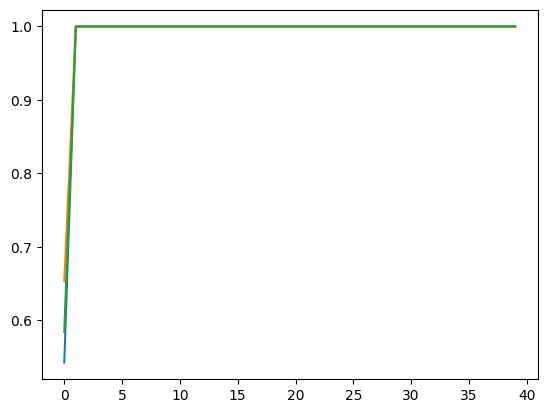

In [88]:
for l in defect_ops_results:
    plt.plot(l[1])

In [89]:
[l[1][-1] for l in defect_ops_results]

[0.9999999999999996, 0.9999999999999998, 0.9999999999999999]

## SPT extraction functions

In [90]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [91]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [92]:
e, a, b, c = symmetry_labels

In [93]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [94]:
defect_ops_results[0][0][1]

Tensor(shape=(4, 4), inds=('b_right', 'k_right'), tags=oset([]))

In [95]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [96]:
symmetry_labels

['II', 'IX', 'XI', 'XX']

In [97]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [98]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

In [103]:
left_defect_sites = [5,6]
right_defect_sites = [11,12]

In [104]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [105]:
left_rdm

Tensor(shape=(4, 4), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ']))

In [106]:
right_rdm

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [107]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [114]:
left_unitaries

(Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([])))

In [117]:
np.round(left_unitaries[0].data, 3)

array([[ 0.966-0.148j,  0.   -0.j   , -0.032-0.212j, -0.   +0.j   ],
       [-0.   +0.j   ,  0.498-0.679j, -0.   +0.j   , -0.435-0.319j],
       [-0.032-0.212j,  0.   -0.j   ,  0.966-0.148j, -0.   +0.j   ],
       [ 0.   +0.j   , -0.435-0.319j, -0.   +0.j   ,  0.498-0.679j]])

In [118]:
np.round(left_unitaries[1].data, 3)

array([[ 1.+0.006j, -0.-0.j   , -0.+0.009j,  0.+0.j   ],
       [ 0.+0.j   , -0.+0.001j,  0.-0.j   , -1.-0.014j],
       [ 0.-0.009j,  0.+0.j   , -1.-0.006j, -0.-0.j   ],
       [ 0.-0.j   ,  1.+0.014j, -0.-0.j   ,  0.-0.001j]])

In [119]:
np.round(left_unitaries[2].data, 3)

array([[-0.966-0.226j, -0.   -0.j   ,  0.029-0.123j,  0.   +0.j   ],
       [ 0.   +0.j   , -0.894+0.089j,  0.   +0.j   ,  0.044+0.438j],
       [-0.029+0.123j,  0.   +0.j   ,  0.966+0.226j, -0.   -0.j   ],
       [-0.   +0.j   , -0.044-0.438j,  0.   -0.j   ,  0.894-0.089j]])

In [108]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [109]:
left_phases

array([-0.75900197+0.65108832j, -0.34410972+0.6177285j ,
       -0.99963486+0.02702104j, -0.65651849+0.26264705j,
       -0.00520607+0.00582416j, -0.93459028-0.14829642j])

In [110]:
left_phases[::2]/left_phases[1::2]

array([1.32675154+0.48962267j, 1.32675154+0.48962267j,
       0.00446908-0.00694091j])

In [122]:
np.round(right_unitaries[0].data, 3)

array([[ 0.896+0.361j,  0.037-0.002j, -0.181+0.012j, -0.181+0.012j],
       [-0.037+0.002j, -0.896-0.361j, -0.181+0.012j, -0.181+0.012j],
       [ 0.16 +0.085j, -0.16 -0.085j,  0.932+0.192j, -0.001-0.168j],
       [-0.16 -0.085j,  0.16 +0.085j,  0.001+0.168j, -0.932-0.192j]])

In [123]:
np.round(right_unitaries[1].data, 3)

array([[ 0.499+0.346j,  0.501-0.362j,  0.322+0.146j,  0.322+0.146j],
       [ 0.501-0.362j,  0.499+0.346j, -0.322-0.146j, -0.322-0.146j],
       [-0.35 +0.043j,  0.35 -0.043j,  0.605-0.346j, -0.395-0.331j],
       [-0.35 +0.043j,  0.35 -0.043j, -0.395-0.331j,  0.605-0.346j]])

In [124]:
np.round(right_unitaries[2].data, 3)

array([[ 0.524-0.177j,  0.414-0.172j,  0.495+0.04j ,  0.495+0.04j ],
       [-0.414+0.172j, -0.524+0.177j,  0.495+0.04j ,  0.495+0.04j ],
       [ 0.496-0.023j, -0.496+0.023j,  0.414-0.179j, -0.523+0.17j ],
       [-0.496+0.023j,  0.496-0.023j,  0.523-0.17j , -0.414+0.179j]])

In [111]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [112]:
right_phases

array([0.06724685+0.08063339j, 0.75900197+0.65108832j,
       0.00271532-0.00640714j, 0.90853275-0.11681288j,
       0.08823842-0.05690224j, 0.73886129-0.67385755j])

In [113]:
right_phases[::2]/right_phases[1::2]

array([0.10353995+0.01741727j, 0.00383206-0.00655949j,
       0.10353995+0.01741727j])

Invariants are totally wrong, shoot.

# Larger system, 4 site defect operators

## Left projector

In [161]:
left_rho_sites = [4]

In [162]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})).contract()

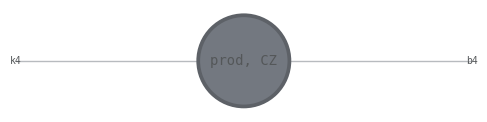

In [163]:
left_rho.draw()

In [164]:
left_score, left_proj_vec = maximize_projector_states(left_rho)

In [165]:
left_score

0.49999999999999645

In [166]:
left_sites = [2,3]
right_sites = [5,6]

In [167]:
larger_sites = left_sites + left_rho_sites + right_sites

In [168]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

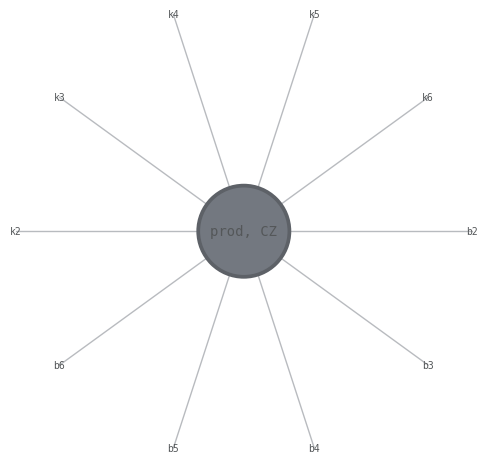

In [169]:
larger_rho.draw()

In [170]:
schmimdt_vals = projector_state_check(
    left_proj_vec,
    larger_rho,
    left_sites
)

In [171]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [172]:
left_proj_vec

Tensor(shape=(2,), inds=('k4',), tags=oset([]))

## Right projector

In [173]:
right_rho_sites = [21]

In [174]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})).contract()

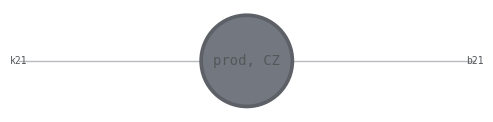

In [175]:
right_rho.draw()

In [176]:
right_score, right_proj_vec = maximize_projector_states(right_rho)

In [177]:
right_score

0.4999999999999965

In [178]:
left_sites = [19,20]
right_sites = [22,23]

In [179]:
larger_sites = left_sites + right_rho_sites + right_sites

In [180]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

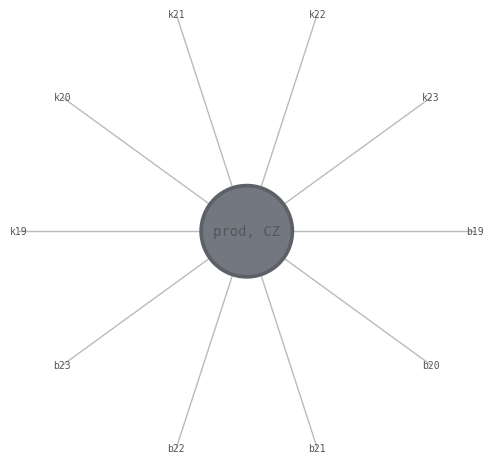

In [181]:
larger_rho.draw()

In [182]:
larger_rho

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k19', 'k20', 'k21', 'k22', 'k23', 'b19', 'b20', 'b21', 'b22', 'b23'), tags=oset(['prod', 'CZ']))

In [183]:
schmimdt_vals = projector_state_check(
    right_proj_vec,
    larger_rho,
    left_sites
)

In [184]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [191]:
proj_psi = (
    psi.reindex({'k4': 'b4', 'k21': 'b21'})
    & left_proj_vec.conj().reindex({'k4': 'b4'})
    & left_proj_vec
    & right_proj_vec.conj().reindex({'k21': 'b21'})
    & right_proj_vec
)

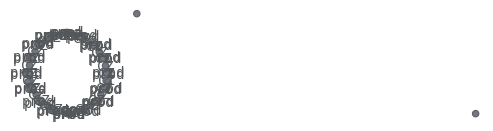

In [192]:
proj_psi.draw()

In [193]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [194]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [195]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [196]:
norm

1.0

## Compute cut rho

In [198]:
cut_sites = list(range(4, 22))

In [199]:
cut_rho_unprojected = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites}))

In [200]:
cut_rho = (
    cut_rho_unprojected.reindex(
        {
            'k4': 'l4',
            'k21': 'l21',
            'b4': 'c4',
            'b21': 'c21',
        }
    )
    & left_proj_vec.conj().reindex({'k4': 'l4'})
    & left_proj_vec
    & left_proj_vec.reindex({'k4': 'c4'})
    & left_proj_vec.conj().reindex({'k4': 'b4'})
    & right_proj_vec.conj().reindex({'k21': 'l21'})
    & right_proj_vec
    & right_proj_vec.reindex({'k21': 'c21'})
    & right_proj_vec.conj().reindex({'k21': 'b21'})
)

In [201]:
cut_rho_trace = (
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

In [202]:
cut_rho_trace

0.24999999999999822

In [203]:
cut_rho = cut_rho/cut_rho_trace

In [204]:
(
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

1.000000000000001

In [205]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in cut_sites}
    | {f'b{i}': f'k{i}' for i in cut_sites}
)

In [206]:
(
    (cut_rho & cut_rho.reindex(tranpose_map))
    .contract()
)

1.000000000000002

So the density matrix is pure, nice.

In [208]:
sub_cut_sites = list(range(5, 21))

In [209]:
sub_cut_rho = (
    cut_rho
    .reindex({'k4': 'b4', 'k21': 'b21'})
)

In [210]:
sub_cut_rho_trace = (
    sub_cut_rho
    .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
    .contract()
)

In [211]:
sub_cut_rho_trace

1.000000000000001

In [212]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [213]:
(
    (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
    .contract()
)

1.000000000000002

## Lanczos algorithm to extract state

In [214]:
v = qtn.Tensor(
    data=random_uniform_complex((2,)*len(sub_cut_sites)),
    inds=[f'k{i}' for i in sub_cut_sites]
)

In [215]:
transpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [216]:
k_to_b_map = {f'k{i}': f'b{i}' for i in sub_cut_sites}

In [217]:
cut_state = lanczos_algorithm(sub_cut_rho, v)

In [218]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19', 'k20'), tags=oset(['prod', 'CZ']))

In [219]:
(cut_state & cut_state.conj()).contract()

(0.9999999999999961+0j)

In [220]:
rho_state = (
    sub_cut_rho & cut_state.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
).contract()

In [221]:
(rho_state & rho_state.conj()).contract()

(1.0000000000000029+0j)

In [222]:
(cut_state & rho_state.conj()).contract()

(0.9999999999999961+0j)

Great, so outputting as we would expect.

## Extract cut rho and EDM

In [223]:
sites = sub_cut_sites
symmetry_pair = symmetry_actions[1]
num_defect_sites = 4

In [226]:
edms = [
    generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        s,
        num_defect_sites
    )
    for s in symmetry_actions[1:]
]

In [227]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

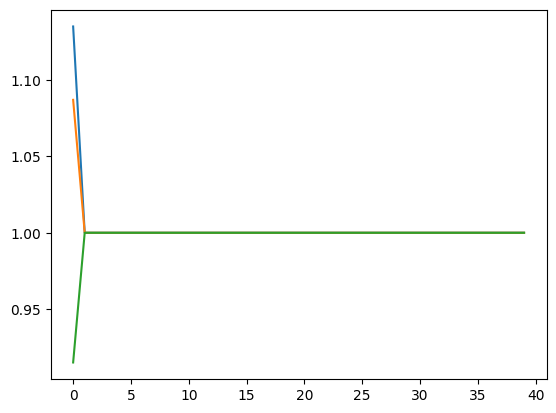

In [228]:
for l in defect_ops_results:
    plt.plot(l[1])

In [229]:
[l[1][-1] for l in defect_ops_results]

[1.0000000000000024, 1.0000000000000024, 1.0000000000000027]

## SPT extraction functions

In [237]:
left_defect_sites = [5,6,7,8]
right_defect_sites = [17,18,19,20]

In [238]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [239]:
left_rdm

Tensor(shape=(16, 16), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ']))

In [240]:
right_rdm

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [241]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [242]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [243]:
left_phases

array([ 0.99913075+0.04168637j,  0.22436528-0.08146924j,
       -0.78409043+0.6206466j , -0.1167823 +0.20817999j,
        0.32977003+0.04494417j,  0.3199289 +0.16063819j])

In [244]:
left_phases[::2]/left_phases[1::2]

array([3.87479208+1.59277208j, 3.87479208+1.59277208j,
       0.87955274-0.3011469j ])

In [245]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [246]:
right_phases

array([-0.18784366+0.10446955j, -0.99913075+0.04168637j,
       -0.05421026+0.1672792j , -0.02393181-0.06967689j,
       -0.15908986+0.14453216j, -0.96333412+0.26830464j])

In [247]:
right_phases[::2]/right_phases[1::2]

array([ 0.19203534-0.09654821j, -1.90842083-1.43350583j,
        0.19203534-0.09654821j])

# Conclusions
Making things bigger doesn't seem to help.

# Old code

## Computing entropies and quantum informaton

In [51]:
def compute_sub_entropy(rho, sub_sites):
    # Assuming rho is a tensor
    sites = [int(i[1:]) for i in rho.inds if i.startswith('b')]
    contract_map = {
        f'b{i}': f'k{i}' for i in sites
        if i not in sub_sites
    }
    sub_rho = (
        rho
        .reindex(contract_map)
        .contract()
        .tranpspose(
            [f'k{i}' for i in sub_sites]
            + [f'b{i}' for i in sub_sites]
        )
        .fuse({
            'k': [f'k{i}' for i in sub_sites],
            'b': [f'b{i}' for i in sub_sites]
        })
        .data
    )

    out = qu.calc.entropy(sub_rho)

    return out